In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('HousingData.csv')
print("✅ Data loaded! Shape:", df.shape)
df.fillna(df.mean(), inplace=True)
print("✅ NAs fixed!")


✅ Data loaded! Shape: (506, 14)
✅ NAs fixed!


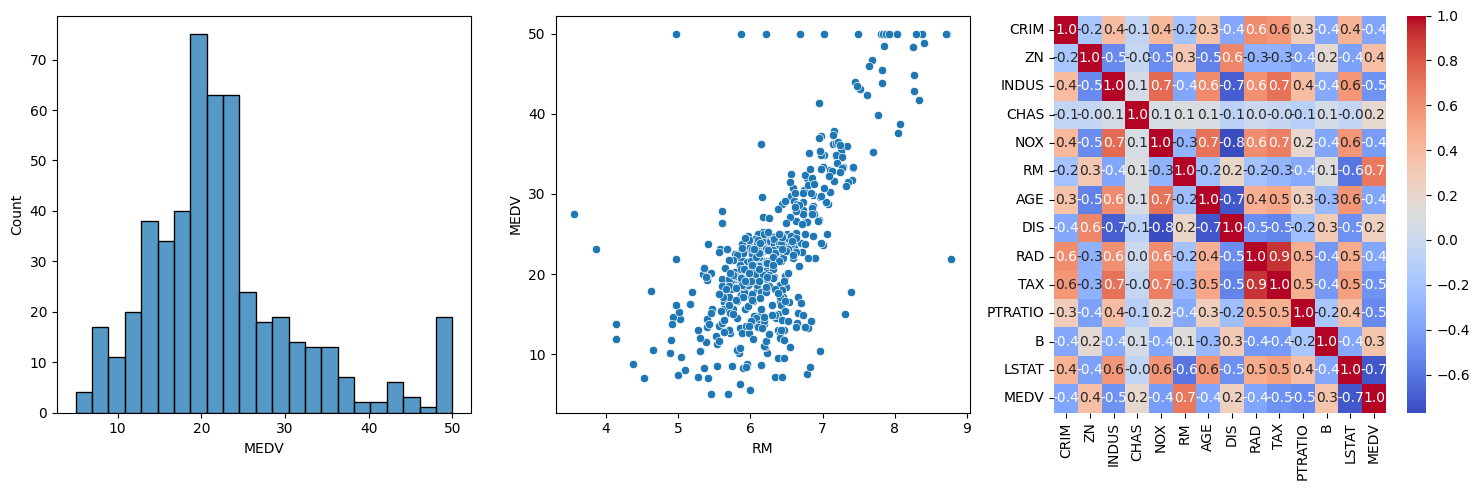

In [14]:
plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
sns.histplot(df['MEDV'])
plt.subplot(1,3,2)
sns.scatterplot(x='RM', y='MEDV', data=df)
plt.subplot(1,3,3)
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.1f')
plt.tight_layout()
plt.savefig('eda_plots.png')
plt.show()


In [16]:
X = df.drop('MEDV', axis=1)
y = df['MEDV']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

lr = LinearRegression().fit(X_train, y_train)
print(f"Linear Regression MSE: {mean_squared_error(y_test, lr.predict(X_test)):.2f}")

gb = GradientBoostingRegressor().fit(X_train, y_train)
print(f"Gradient Boosting MSE: {mean_squared_error(y_test, gb.predict(X_test)):.2f}")


Linear Regression MSE: 33.75
Gradient Boosting MSE: 19.07
